In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

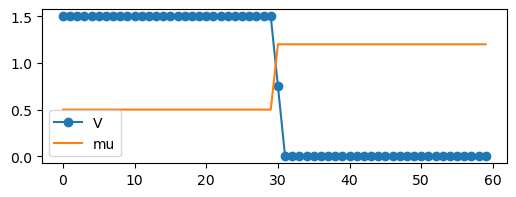

In [2]:
widthN = 30
widthP = 30

X, Y = widthN+widthP, 100
lattice = Lattice(X, Y)
t = 1
T=0.001

muN = 1.2 * t
muP = 0.5 * t
mu = np.zeros(lattice.X)
mu[:widthP] = muP
mu[widthP:] = muN

U = None
V_prime = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthP:] = 0
V[widthP] = V0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

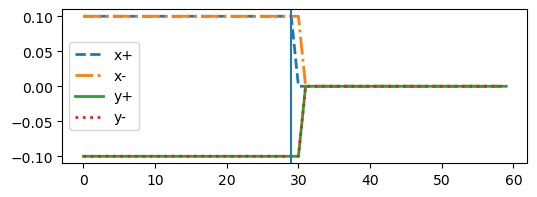

In [3]:
H = Hamiltonian(t, mu, lattice,
                U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1])

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.real(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.real(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [4]:
_,_,_,_ = bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=500, verbose=False, temperature=T)

Converged after 72 iterations


In [5]:
F, Fuu, Fdd = H.get_correlations()

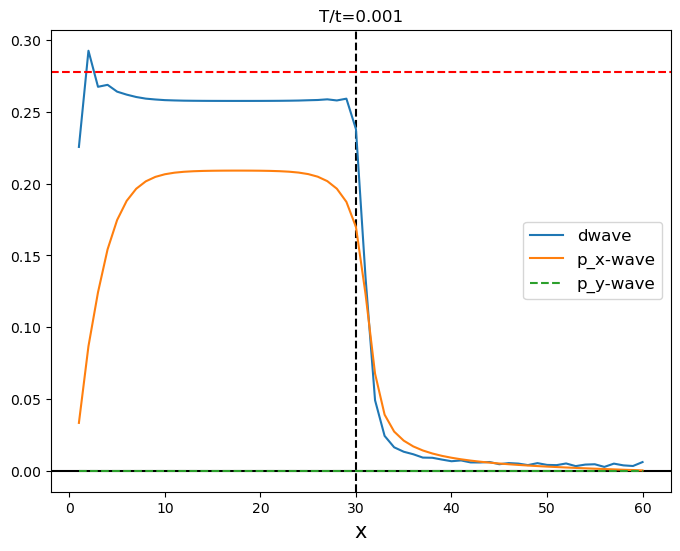

In [6]:
x = np.arange(1, widthN + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}")
axs.axhline(0, color = 'black')
axs.axvline(widthN, color='black', linestyle='--')
axs.plot(x, np.real(F.dwave), label="dwave")
axs.plot(x, np.real(F.px), label="p_x-wave")
axs.plot(x, np.imag(F.py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 45)
# axs.set_ylim(None, 0.3)
axs.axhline(0.278, linestyle='--', color="red")

axs.legend(fontsize=12, loc="best")
plt.show()